In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import statsmodels.api as sm 
import seaborn as sns
from statsmodels.stats.outliers_influence import OLSInfluence

In [2]:
expenditure = [10, 20, 30, 40, 50, 100] 
sales = [15, 25, 35, 45, 60, 200] 

In [3]:
x = np.array(expenditure)
y = np.array(sales)

In [4]:
#scatter plot

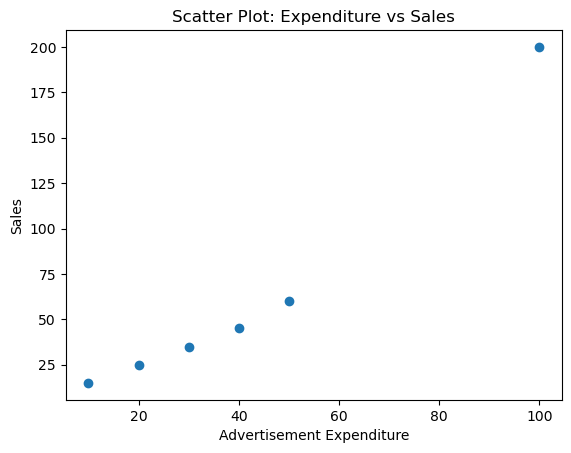

In [6]:
plt.scatter(expenditure, sales) 
plt.xlabel("Advertisement Expenditure") 
plt.ylabel("Sales") 
plt.title("Scatter Plot: Expenditure vs Sales") 
plt.show() 


In [7]:
#covariance using np

In [8]:
cv=np.cov(expenditure, sales)

In [9]:
print(cv)
cvn = cv[0,1]
print(cvn)

[[1016.66666667 2133.33333333]
 [2133.33333333 4726.66666667]]
2133.3333333333335


In [10]:
#covariance manual

In [11]:
meanx = np.mean(x)

In [12]:
meany = np.mean(y)

In [13]:
diffx = x - meanx

In [14]:
diffy = y- meany

In [15]:
product = diffx*diffy

In [23]:
covariance = np.sum(product)/len(x)

In [17]:
print(f'Covariance = {covariance}')

Covariance = 1777.7777777777776


In [18]:
#since by using cov its hard to interpret the outcome but still its +ive so relation is positve. 
# to overcome this we will use correlation coefficient

In [19]:
#Pearson Correlation Method – measures both direction and strength of relationship between two 
#variables. 

In [20]:
corr = np.corrcoef(x,y)
corrn= corr[0,1]
print(f'Correlation = {corrn}')

Correlation = 0.9731772298940702


In [21]:
#Extra

In [22]:
#hyp testing

In [29]:
x_with_const = sm.add_constant(x)

In [32]:
print(X_with_const)

[[  1.  10.]
 [  1.  20.]
 [  1.  30.]
 [  1.  40.]
 [  1.  50.]
 [  1. 100.]]


In [33]:
print(X_with_const.shape)

(6, 2)


In [34]:
model = sm.OLS(y, x_with_const).fit()

In [36]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     71.58
Date:                Thu, 26 Feb 2026   Prob (F-statistic):            0.00107
Time:                        16:36:34   Log-Likelihood:                -24.533
No. Observations:                   6   AIC:                             53.07
Df Residuals:                       4   BIC:                             52.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -24.0984     12.606     -1.912      0.1

C:\Users\best buy\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [37]:
print("\n--- Specific Hypothesis Testing Results ---") 
print(f"Intercept (Beta0): {model.params[0]:.4f} | P-value: {model.pvalues[0]:.4f}") 
print(f"Slope (Beta1): {model.params[1]:.4f} | P-value: {model.pvalues[1]:.4f}") 


--- Specific Hypothesis Testing Results ---
Intercept (Beta0): -24.0984 | P-value: 0.1285
Slope (Beta1): 2.0984 | P-value: 0.0011


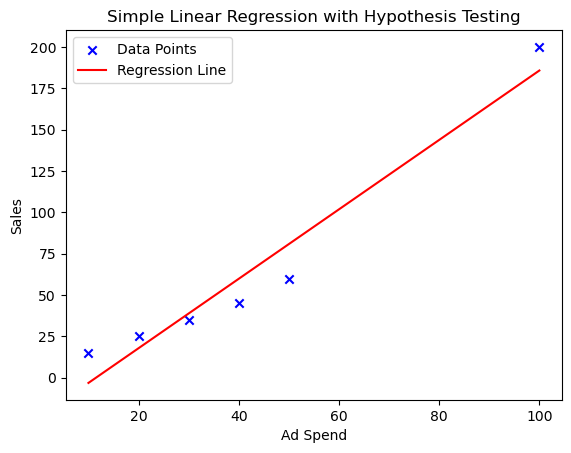

In [41]:
plt.scatter(x, y, marker='x',color='blue', label='Data Points') 
plt.plot(x, model.predict(x_with_const), color='red', label='Regression Line') 
plt.xlabel('Ad Spend') 
plt.ylabel('Sales') 
plt.legend() 
plt.title('Simple Linear Regression with Hypothesis Testing') 
plt.show()

In [57]:
#interval estimation

In [44]:
predictions = model.get_prediction(x_with_const) 
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

In [45]:
mean_ci_lower = summary_frame['mean_ci_lower'] 
mean_ci_upper = summary_frame['mean_ci_upper'] 
obs_ci_lower = summary_frame['obs_ci_lower'] 
obs_ci_upper = summary_frame['obs_ci_upper']

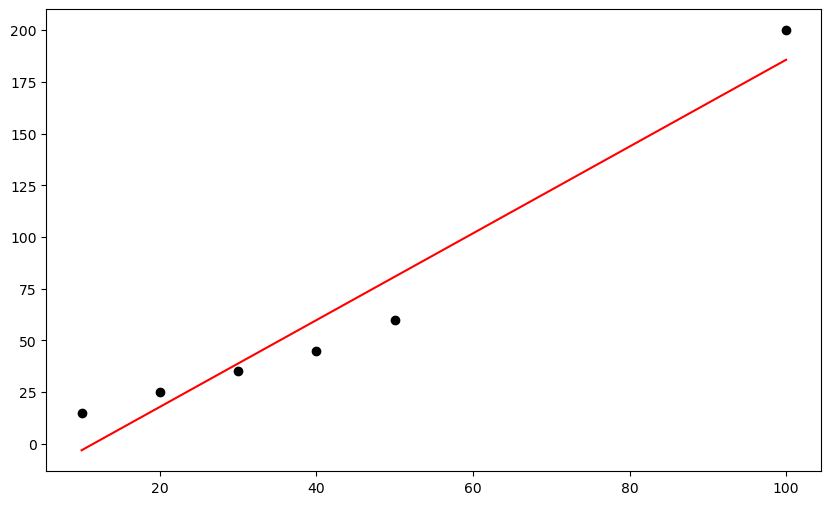

In [47]:
plt.figure(figsize=(10, 6)) 
plt.scatter(x, y, color='black', label='Observed Data') 
plt.plot(x, model.fittedvalues, color='red', label='Regression Line')

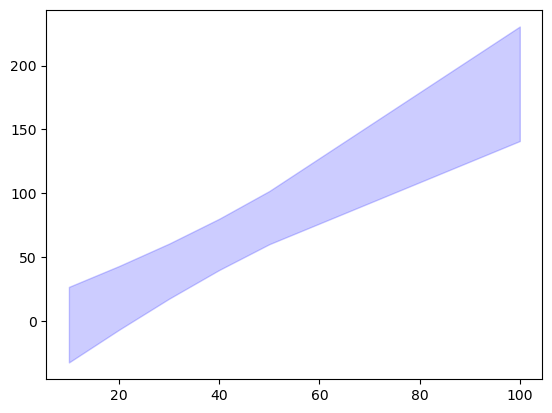

In [49]:
plt.fill_between(x, mean_ci_lower, mean_ci_upper, color='blue', alpha=0.2, label='95% Conf.Interval (Mean)')

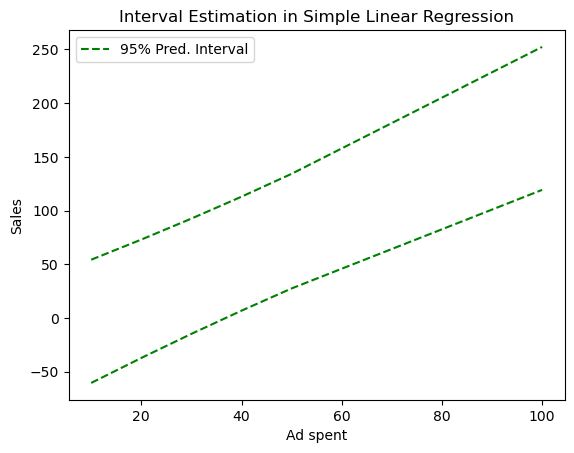

In [52]:
plt.plot(x, obs_ci_lower, 'g--', label='95% Pred. Interval') 
plt.plot(x, obs_ci_upper, 'g--') 
plt.xlabel('Ad spent') 
plt.ylabel('Sales') 
plt.title('Interval Estimation in Simple Linear Regression') 
plt.legend() 
plt.show()

In [56]:
test_val = [1, 75] 
spec_pred = model.get_prediction(test_val).summary_frame(alpha=0.05) 
print(f"\nFor 75Rs of spent:") 
print(f"Predicted Score: {spec_pred['mean'].values[0]:.2f}") 
print(f"95% Confidence Interval: [{spec_pred['mean_ci_lower'].values[0]:.2f},{spec_pred['mean_ci_upper'].values[0]:.2f}]") 
print(f"95% Prediction Interval: [{spec_pred['obs_ci_lower'].values[0]:.2f},{spec_pred['obs_ci_upper'].values[0]:.2f}]")


For 75Rs of spent:
Predicted Score: 133.28
95% Confidence Interval: [102.80,163.75]
95% Prediction Interval: [75.49,191.06]


In [58]:
#Reidual checking

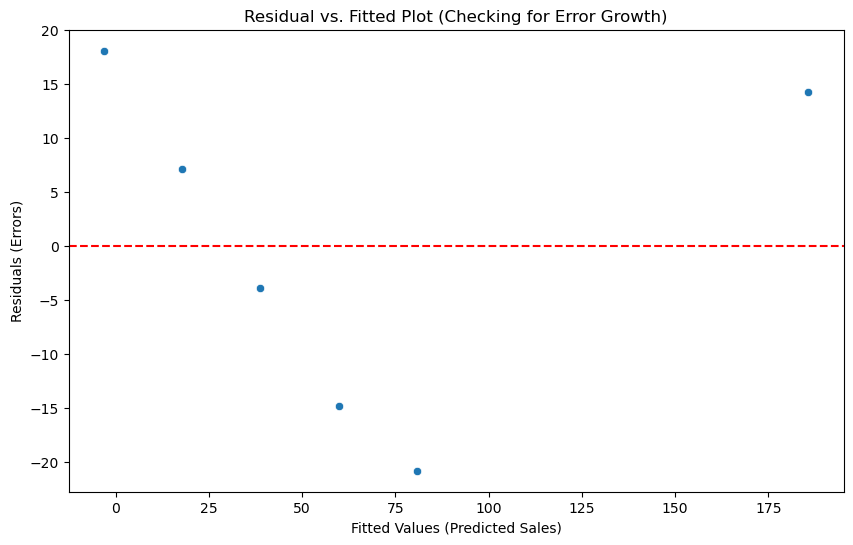

In [62]:
# 1. Get the residuals (Actual - Predicted)
residuals = model.resid

# 2. Get the fitted values (The Predictions)
fitted_values = model.fittedvalues

# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')  # The "Zero Error" line

plt.title('Residual vs. Fitted Plot (Checking for Error Growth)')
plt.xlabel('Fitted Values (Predicted Sales)')
plt.ylabel('Residuals (Errors)')
plt.show()

In [63]:
#"Leverage Points"

In [66]:
influence = OLSInfluence(model)
leverage = influence.hat_matrix_diag

In [67]:
leverage_df = pd.DataFrame({
    'Expenditure': expenditure,
    'Leverage': leverage
})

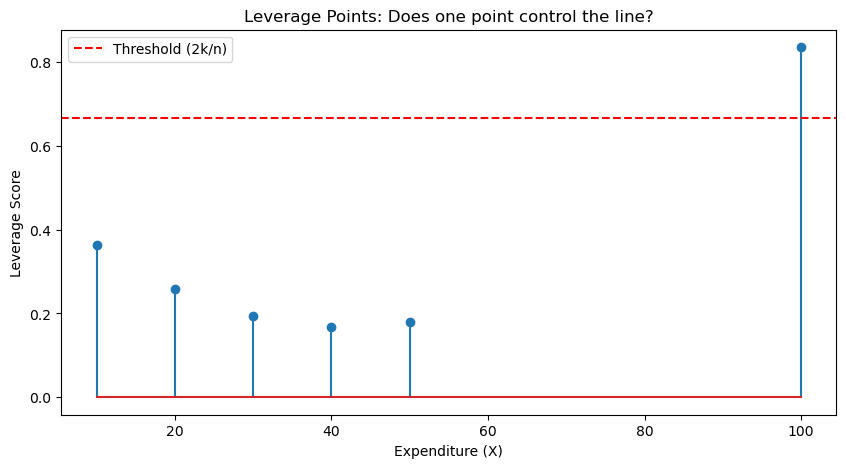

In [69]:
# Plotting Leverage
plt.figure(figsize=(10, 5))
plt.stem(expenditure, leverage)
plt.axhline(y=2*2/6, color='red', linestyle='--', label='Threshold (2k/n)') #$k is (Number of Parameters) and n  is(Number of Observations)
plt.title('Leverage Points: Does one point control the line?')
plt.xlabel('Expenditure (X)')
plt.ylabel('Leverage Score')
plt.legend()
plt.show()

In [70]:
#"Cook's Distance" in Python to see exactly how much your slope ($\beta_1$) would change if you deleted that ₹100 data point

In [71]:
(cooks, pvals) = influence.cooks_distance

In [74]:
influence_df = pd.DataFrame({
    'Expenditure': expenditure,
    'Sales': sales,
    'Cooks_Distance': cooks
})

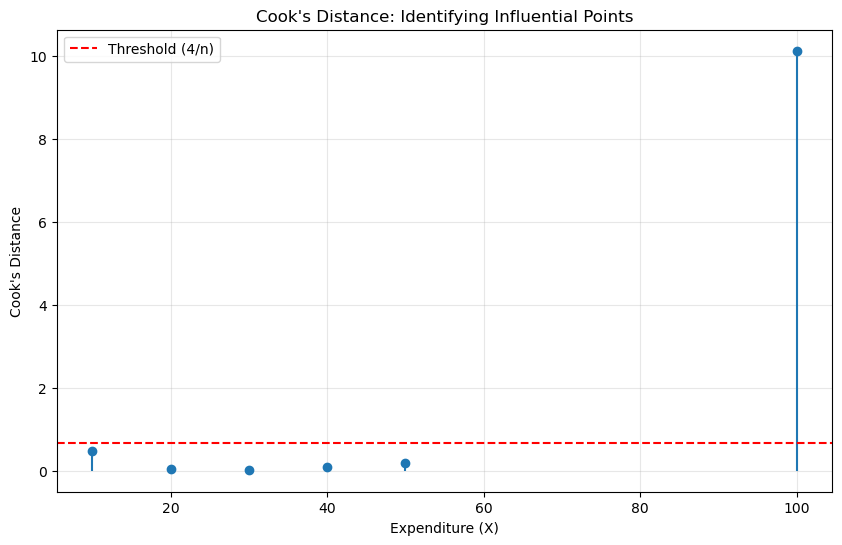

In [75]:
plt.figure(figsize=(10, 6))
plt.stem(expenditure, cooks, basefmt=" ")
plt.axhline(y=4/len(expenditure), color='red', linestyle='--', label='Threshold (4/n)')
plt.title("Cook's Distance: Identifying Influential Points")
plt.xlabel('Expenditure (X)')
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [76]:
print(influence_df)
print(f"\nThreshold (4/n): {4/len(expenditure):.4f}")

   Expenditure  Sales  Cooks_Distance
0           10     15        0.471976
1           20     25        0.038359
2           30     35        0.007057
3           40     45        0.084855
4           50     60        0.186023
5          100    200       10.118453

Threshold (4/n): 0.6667


In [77]:
#"Sensitivity Analysis"
#re-calculate the model without that ₹100 point so you can see how much the "Sales Forecast" changes.

              Metric  Original Model  Filtered Model
0      Slope (Beta1)        2.098361        1.100000
1  Intercept (Beta0)      -24.098361        3.000000
2          R-squared        0.947074        0.991803
3    P-value (Slope)        0.001070        0.000316


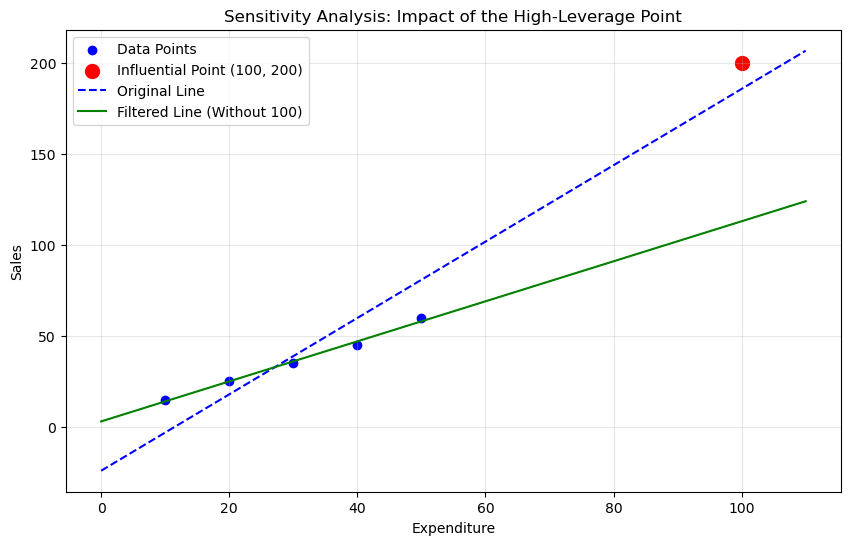

In [78]:
# Original Data
exp = np.array([10, 20, 30, 40, 50, 100])
sales = np.array([15, 25, 35, 45, 60, 200])

# Filtered Data (removing the outlier at 100)
exp_filtered = exp[:-1]
sales_filtered = sales[:-1]

# Model 1: Original
X1 = sm.add_constant(exp)
model1 = sm.OLS(sales, X1).fit()

# Model 2: Filtered
X2 = sm.add_constant(exp_filtered)
model2 = sm.OLS(sales_filtered, X2).fit()

# Comparison Table
comparison = {
    "Metric": ["Slope (Beta1)", "Intercept (Beta0)", "R-squared", "P-value (Slope)"],
    "Original Model": [model1.params[1], model1.params[0], model1.rsquared, model1.pvalues[1]],
    "Filtered Model": [model2.params[1], model2.params[0], model2.rsquared, model2.pvalues[1]]
}
df_comp = pd.DataFrame(comparison)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(exp, sales, color='blue', label='Data Points')
plt.scatter(100, 200, color='red', s=100, label='Influential Point (100, 200)')

# Lines
x_range = np.linspace(0, 110, 100)
plt.plot(x_range, model1.predict(sm.add_constant(x_range)), color='blue', linestyle='--', label='Original Line')
plt.plot(x_range, model2.predict(sm.add_constant(x_range)), color='green', label='Filtered Line (Without 100)')

plt.title('Sensitivity Analysis: Impact of the High-Leverage Point')
plt.xlabel('Expenditure')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('sensitivity_analysis.png')

print(df_comp)

In [79]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     363.0
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           0.000316
Time:                        18:14:30   Log-Likelihood:                -8.8276
No. Observations:                   5   AIC:                             21.66
Df Residuals:                       3   BIC:                             20.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0000      1.915      1.567      0.2

C:\Users\best buy\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
